# 01 — รู้จัก AOD และ PM2.5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nattaponm/Teach_AOD_PM_PCD/blob/main/01_AOD_and_PM25_Basics.ipynb)

## จุดประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตสามารถ
1. อธิบายได้ว่า **AOD** และ **PM2.5** วัดอะไร และต่างกันอย่างไร
2. ใช้กฎ Beer–Lambert คำนวณสัดส่วนแสงที่ผ่านชั้นบรรยากาศได้
3. อ่านแผนที่ AOD จากดาวเทียมและแผนที่ PM2.5 จากสถานีภาคพื้นดิน
4. บรรยายรูปแบบเชิงพื้นที่และเชิงเวลาของฝุ่นช่วง ก.พ.–เม.ย. 2023

**เวลาโดยประมาณ** 90 นาที · **ข้อมูล** PCD (PM2.5 รายวัน) และ MODIS MAIAC `MCD19A2` (AOD 1 km)

> **วิธีเรียน** — อ่านคำอธิบาย → รันทีละ cell → ดูผล → ตอบคำถาม "ลองคิด" ในใจก่อนรัน cell ถัดไป
> ไม่แนะนำให้กด *Run all* ในรอบแรก

## 1. ทำไมต้องเรียนเรื่องนี้

เมื่อวันที่ 19 พ.ค. 2569 กรมควบคุมมลพิษ (คพ.) แถลงว่าสถานการณ์ PM2.5 กลับสู่ภาวะปกติหลังเข้าฤดูฝน
และระบุว่าช่วงต้นปี ภาคเหนือ กรุงเทพฯ-ปริมณฑล ภาคกลาง และภาคตะวันออกเฉียงเหนือ ได้รับผลกระทบจาก
**การสะสมของฝุ่นในพื้นที่ สภาพอากาศปิด และหมอกควันข้ามแดน** ([Thai PBS](https://www.thaipbs.or.th/news/content/506117))

ปัญหาคือ สถานีตรวจวัดมีราวร้อยแห่ง แต่ประเทศไทยมีพื้นที่กว่า 5 แสนตารางกิโลเมตร

```
สถานีภาคพื้นดิน  →  แม่นยำ วัดต่อเนื่อง แต่เป็น "จุด"
ดาวเทียม         →  ครอบคลุมทั้งประเทศ แต่วัด "ทางอ้อม" และมองไม่ทะลุเมฆ
```

ชุดบทเรียนนี้จึงถามว่า **เราใช้ AOD จากดาวเทียมบอกค่า PM2.5 ที่พื้นดินได้ดีแค่ไหน**
โดยใช้ช่วง **กุมภาพันธ์–เมษายน 2023** ซึ่งเป็นปีที่ฝุ่นรุนแรงที่สุดในข้อมูลปี 2021–2025

## 2. หลักการ: สองตัวแปรที่ดูคล้ายแต่ไม่เหมือนกัน

| | PM2.5 | AOD |
|---|---|---|
| ชื่อเต็ม | Particulate Matter ≤ 2.5 µm | Aerosol Optical Depth (ความลึกเชิงแสงของละอองลอย) |
| วัดอะไร | **มวล** ของฝุ่นในอากาศ 1 ลูกบาศก์เมตร | ละอองลอย **ลดทอนแสง** ไปมากเท่าใด |
| วัดที่ไหน | ระดับพื้นดิน (ที่เราหายใจ) | **ตลอดทั้งคอลัมน์** จากพื้นดินถึงขอบบรรยากาศ |
| หน่วย | µg/m³ | ไม่มีหน่วย |
| เวลา | เฉลี่ย 24 ชั่วโมง | ขณะดาวเทียมผ่าน (ประมาณ 10:30 และ 13:30 น.) |

### สมการสำคัญ: กฎ Beer–Lambert

$$I = I_0 \, e^{-\tau/\mu}$$

| สัญลักษณ์ | ความหมาย |
|---|---|
| $I_0$ | ความเข้มแสงอาทิตย์ที่ขอบบรรยากาศ |
| $I$ | ความเข้มแสงที่เหลือเมื่อถึงพื้นดิน |
| $\tau$ | AOD ยิ่งมากแสงยิ่งถูกลดทอน |
| $\mu$ | cosine ของมุมที่ดวงอาทิตย์ทำกับแนวดิ่ง ($\mu = 1$ เมื่อดวงอาทิตย์อยู่เหนือศีรษะ) |

**อ่านสมการแบบง่าย** — แสงลดลงแบบ exponential ตามปริมาณละอองลอยที่ขวางทาง

**ตัวอย่าง** ถ้า $\tau = 0.5$ และดวงอาทิตย์อยู่เหนือศีรษะ

$$\frac{I}{I_0} = e^{-0.5} \approx 0.61$$

แสงตรงจากดวงอาทิตย์เหลือถึงพื้นประมาณ 61% อีก 39% ถูกละอองลอยกระเจิงหรือดูดกลืน

## 0. เตรียมเครื่องมือ

Cell ชุดนี้เหมือนกันทุก Notebook ทำ 3 อย่าง คือ โหลด library, ดาวน์โหลดข้อมูลจาก GitHub ของรายวิชา และสร้างฟังก์ชันแผนที่มาตรฐาน
รันทีละ cell ตามลำดับ ไม่จำเป็นต้องอ่านโค้ดส่วนนี้ละเอียดในรอบแรก

In [1]:
!pip -q install rasterio

In [2]:
from pathlib import Path
import urllib.request
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import rasterio
from rasterio.plot import plotting_extent

warnings.filterwarnings("ignore")

YEAR = 2023
DATA_URL = "https://raw.githubusercontent.com/nattaponm/Teach_AOD_PM_PCD/main/data/"
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def fetch(name):
    # ดาวน์โหลดไฟล์จาก GitHub มาเก็บในโฟลเดอร์ data (โหลดครั้งเดียว)
    path = DATA_DIR / name
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

In [3]:
# รูปแบบภาพสำหรับงานตีพิมพ์: ตัวอักษรอ่านง่าย เส้นบาง ความละเอียด 300 dpi
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "legend.fontsize": 8, "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
})

UNIT = "µg m$^{-3}$"

def save_fig(fig, name):
    # บันทึกทั้ง PNG (ใส่รายงาน) และ PDF (ส่งวารสาร)
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")
    print("บันทึกแล้ว:", FIG_DIR / f"{name}.png", "และ .pdf")

In [4]:
# ขอบเขต 77 จังหวัด และเส้นขอบประเทศ (รวมทุกจังหวัดเป็นรูปเดียว)
provinces = gpd.read_file(fetch("provinces.geojson"))
country = gpd.GeoSeries([provinces.buffer(0.002).union_all().buffer(-0.002)], crs=provinces.crs)

MAP_EXTENT = [97.0, 106.0, 5.3, 20.8]   # west, east, south, north

def base_map(ax, title=None, province_color="0.45"):
    # วาดองค์ประกอบแผนที่มาตรฐาน: จังหวัด ประเทศ พิกัด มาตราส่วน ทิศเหนือ
    provinces.boundary.plot(ax=ax, linewidth=0.25, color=province_color, zorder=3)
    country.boundary.plot(ax=ax, linewidth=0.9, color="black", zorder=4)

    ax.set_xlim(MAP_EXTENT[0], MAP_EXTENT[1]); ax.set_ylim(MAP_EXTENT[2], MAP_EXTENT[3])
    ax.set_aspect(1 / np.cos(np.deg2rad(13)))          # แก้การยืดของลองจิจูดที่ละติจูด ~13°N
    ax.set_xticks(np.arange(98, 107, 2)); ax.set_yticks(np.arange(6, 21, 2))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°N"))
    ax.tick_params(direction="in", top=True, right=True, length=3)
    ax.grid(linewidth=0.3, color="0.8", linestyle=":", zorder=0)

    # มาตราส่วน 200 km (1 องศาลองจิจูด = 111.32 x cos(ละติจูด) km)
    lat0, lon0 = 6.1, 102.9
    width = 200 / (111.32 * np.cos(np.deg2rad(lat0)))
    ax.plot([lon0, lon0 + width], [lat0, lat0], color="black", linewidth=1.5, zorder=5)
    ax.text(lon0 + width / 2, lat0 + 0.18, "200 km", ha="center", va="bottom", fontsize=7)

    # ลูกศรทิศเหนือ
    ax.annotate("N", xy=(105.2, 20.2), xytext=(105.2, 19.2), ha="center", va="center", fontsize=9,
                arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1))
    ax.set_xlabel(""); ax.set_ylabel("")              # พิกัดบอกอยู่ที่ตัวเลขแกนแล้ว
    if title:
        ax.set_title(title)
    return ax

print("จำนวนจังหวัด:", len(provinces))

จำนวนจังหวัด: 77


In [5]:
# ลองคำนวณ: AOD เท่าใด แสงเหลือเท่าใด
for tau in [0.1, 0.5, 1.0, 2.0]:
    transmittance = np.exp(-tau / 1.0)        # mu = 1
    print(f"AOD = {tau:3.1f}  ->  แสงตรงเหลือ {transmittance * 100:5.1f}%")

AOD = 0.1  ->  แสงตรงเหลือ  90.5%
AOD = 0.5  ->  แสงตรงเหลือ  60.7%
AOD = 1.0  ->  แสงตรงเหลือ  36.8%
AOD = 2.0  ->  แสงตรงเหลือ  13.5%


> 💭 **ลองคิด** — วันที่ท้องฟ้าขุ่นจนมองไม่เห็นดอยสุเทพ ค่า AOD น่าจะอยู่ราวเท่าใด

## 3. ข้อมูล PM2.5 จากสถานี PCD

ไฟล์ `pm25_long.csv` มี 3 คอลัมน์ คือ วันที่ รหัสสถานี และค่า PM2.5 รายวัน
ไฟล์ `stations.geojson` บอกพิกัด จังหวัด และภาคของแต่ละสถานี

In [6]:
pm = pd.read_csv(fetch("pm25_long.csv"), parse_dates=["date"])
stations = gpd.read_file(fetch("stations.geojson"))

print("ช่วงเวลา:", pm["date"].min().date(), "ถึง", pm["date"].max().date())
print("จำนวนสถานี:", pm["station"].nunique(), "| สถานีที่มีพิกัด:", len(stations))
pm.head()

ช่วงเวลา: 2023-02-01 ถึง 2023-04-30
จำนวนสถานี: 96 | สถานีที่มีพิกัด: 93


,date,station,pm25
0,2023-02-01,02T,87.0
1,2023-02-02,02T,100.0
2,2023-02-03,02T,40.0
3,2023-02-04,02T,27.0
4,2023-02-05,02T,22.0


In [7]:
# สถิติพื้นฐานของ PM2.5 ทั้งประเทศ
pm["pm25"].describe().round(1)

,pm25
count,7604.0
mean,48.0
std,35.8
min,8.0
25%,25.0
50%,41.0
75%,58.0
max,586.0


> 💭 **ลองคิด** — ค่า mean สูงกว่า median (50%) บอกอะไรเกี่ยวกับรูปร่างการกระจายของข้อมูล

### ภาพที่ 1 — แผนที่ค่าเฉลี่ย PM2.5 รายสถานี

คำนวณค่าเฉลี่ยตลอด 3 เดือนของแต่ละสถานี แล้ววางบนแผนที่ 77 จังหวัด

บันทึกแล้ว: figures/fig01_station_mean_pm25.png และ .pdf


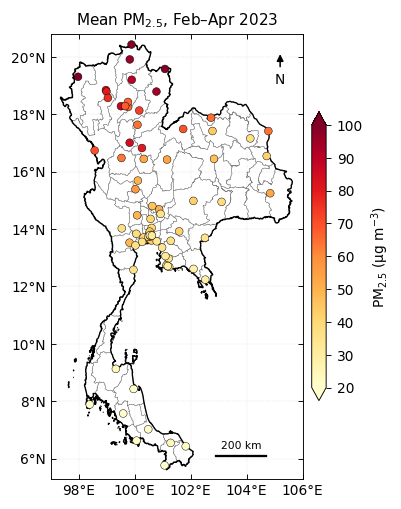

In [8]:
station_mean = pm.groupby("station")["pm25"].mean().rename("pm25_mean").reset_index()
stations_pm = stations.merge(station_mean, on="station")

fig, ax = plt.subplots(figsize=(3.6, 6.2))
base_map(ax, f"Mean PM$_{{2.5}}$, Feb–Apr {YEAR}")
sc = ax.scatter(stations_pm["lon"], stations_pm["lat"], c=stations_pm["pm25_mean"],
                cmap="YlOrRd", vmin=20, vmax=100, s=26, edgecolor="black", linewidth=0.3, zorder=6)
fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.03, extend="both", label=f"PM$_{{2.5}}$ ({UNIT})")
save_fig(fig, "fig01_station_mean_pm25")
plt.show()

## 4. ข้อมูล AOD จากดาวเทียม

ไฟล์ `aod_2023_03.tif` เป็นภาพ AOD เฉลี่ยเดือนมีนาคม ความละเอียด 1 km จากผลิตภัณฑ์ MAIAC (`MCD19A2`)
ผู้สอนเตรียมไว้ใน Notebook 00 โดยเก็บเฉพาะ pixel คุณภาพดีที่สุด (ไม่มีเมฆ)

ภาพมี 3 แบนด์: (1) AOD ที่ 550 nm, (2) ไอน้ำในคอลัมน์, (3) จำนวนวันที่ pixel นั้นมีค่า

### ภาพที่ 2 — แผนที่ AOD เดือนมีนาคม

บันทึกแล้ว: figures/fig02_aod_march.png และ .pdf


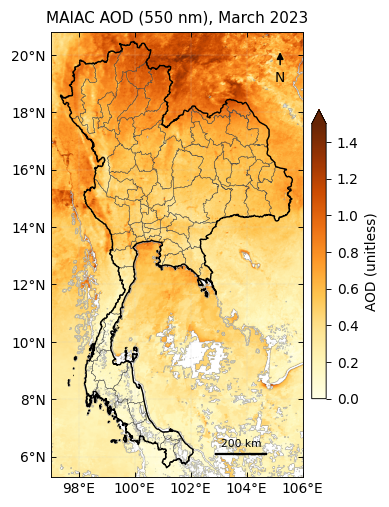

In [9]:
with rasterio.open(fetch(f"aod_{YEAR}_03.tif")) as src:
    aod_march = src.read(1, masked=True)
    aod_march = np.ma.masked_invalid(aod_march)
    raster_extent = plotting_extent(src)

fig, ax = plt.subplots(figsize=(3.6, 6.2))
im = ax.imshow(aod_march, extent=raster_extent, cmap="YlOrBr", vmin=0, vmax=1.5, zorder=1)
base_map(ax, f"MAIAC AOD (550 nm), March {YEAR}", province_color="0.3")
fig.colorbar(im, ax=ax, shrink=0.55, pad=0.03, extend="max", label="AOD (unitless)")
save_fig(fig, "fig02_aod_march")
plt.show()

> 💭 **ลองคิด** — เปรียบเทียบภาพที่ 1 กับภาพที่ 2 บริเวณใดสูงตรงกัน บริเวณใดไม่ตรงกัน
> และสังเกตนอกเขตประเทศไทย AOD สูงต่อเนื่องข้ามพรมแดนหรือไม่

## 5. PM2.5 เปลี่ยนตามเวลาอย่างไร

### ภาพที่ 3 — อนุกรมเวลาค่าเฉลี่ยรายภาค

เส้นประคือค่ามาตรฐานเฉลี่ย 24 ชั่วโมงของไทย: **50 µg/m³** (ใช้ถึง 31 พ.ค. 2566) และ **37.5 µg/m³** (ตั้งแต่ 1 มิ.ย. 2566)

บันทึกแล้ว: figures/fig03_pm25_timeseries_region.png และ .pdf


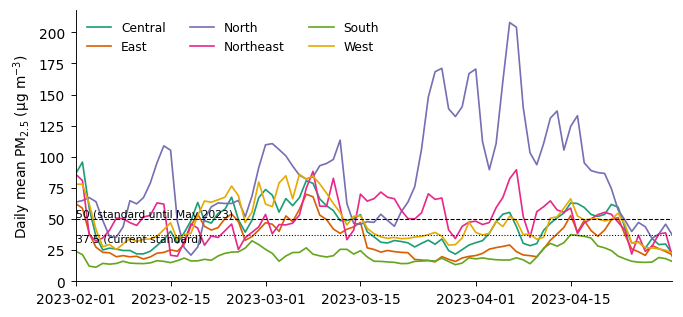

In [10]:
pm_region = pm.merge(stations[["station", "region"]], on="station")
daily_region = pm_region.groupby(["date", "region"])["pm25"].mean().unstack()

fig, ax = plt.subplots(figsize=(7.0, 3.2))
colors = plt.cm.Dark2(np.linspace(0, 1, 8))
for color, region in zip(colors, daily_region.columns):
    ax.plot(daily_region.index, daily_region[region], linewidth=1.1, color=color, label=region)
ax.axhline(50, color="black", linestyle="--", linewidth=0.7)
ax.axhline(37.5, color="black", linestyle=":", linewidth=0.7)
ax.text(daily_region.index[0], 51.5, "50 (standard until May 2023)", fontsize=7)
ax.text(daily_region.index[0], 31.5, "37.5 (current standard)", fontsize=7)
ax.set_ylabel(f"Daily mean PM$_{{2.5}}$ ({UNIT})")
ax.set_xlim(daily_region.index[0], daily_region.index[-1]); ax.set_ylim(0, None)
ax.legend(ncol=3, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "fig03_pm25_timeseries_region")
plt.show()

## 6. สรุป

```
AOD   = ละอองลอยทั้งคอลัมน์ ลดทอนแสงเท่าใด   (ไม่มีหน่วย มองจากอวกาศ)
PM2.5 = มวลฝุ่นที่ระดับพื้นดิน               (µg/m³ วัดที่สถานี)
```

สองค่านี้มัก **ไปด้วยกัน** แต่ **ไม่เท่ากัน** เพราะ
- ควันอาจลอยสูงเหนือพื้นดิน: AOD สูงแต่ PM2.5 ที่พื้นไม่สูง
- ชั้นผสม (mixing layer) ตื้น: ฝุ่นถูกกดไว้ใกล้พื้น PM2.5 สูงแม้ AOD ปานกลาง
- ความชื้นทำให้อนุภาคพองตัว กระเจิงแสงมากขึ้นโดยมวลแห้งไม่เปลี่ยน

Notebook ถัดไปจะนำสองข้อมูลนี้มา **จับคู่** กัน

---
## แบบฝึกหัด

ทำในช่องว่างใต้โจทย์ก่อน แล้วจึงเปิดเฉลย

### ข้อ 1 (ฝึกทำ) — Beer–Lambert
คำนวณสัดส่วนแสงตรงที่เหลือถึงพื้น เมื่อ AOD = 1.5 ในสองกรณี
(ก) ดวงอาทิตย์อยู่เหนือศีรษะ ($\mu = 1$) (ข) ดวงอาทิตย์ทำมุม 60° กับแนวดิ่ง ($\mu = \cos 60°$)

In [11]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: transmittance = np.exp(-tau / mu)   และ   mu = np.cos(np.deg2rad(60))

my_answer_a = None   # ใส่คำตอบข้อ (ก) เป็นสัดส่วน 0-1 เช่น 0.61

In [12]:
#@title ตรวจคำตอบข้อ 1 (ก) (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
_expected = np.exp(-1.5)
if my_answer_a is None:
    print("ยังไม่ได้ใส่คำตอบใน my_answer_a")
elif abs(my_answer_a - _expected) < 0.01:
    print("ถูกต้อง")
else:
    print("ยังไม่ใช่ ตรวจว่าใช้เครื่องหมายลบในเลขชี้กำลัง และตอบเป็นสัดส่วน ไม่ใช่เปอร์เซ็นต์")

ยังไม่ได้ใส่คำตอบใน my_answer_a


In [13]:
#@title เฉลยข้อ 1 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
tau = 1.5
for label, mu in [("(ก) เหนือศีรษะ", 1.0), ("(ข) มุม 60 องศา", np.cos(np.deg2rad(60)))]:
    print(f"{label}: mu = {mu:.2f} -> แสงเหลือ {np.exp(-tau / mu) * 100:.1f}%")

(ก) เหนือศีรษะ: mu = 1.00 -> แสงเหลือ 22.3%
(ข) มุม 60 องศา: mu = 0.50 -> แสงเหลือ 5.0%


<details>
<summary><b>คำอธิบายข้อ 1</b> (คลิกเพื่อเปิด)</summary>

(ก) $e^{-1.5} \approx 0.22$ แสงเหลือ 22%  (ข) $\mu = 0.5$ จึงได้ $e^{-3} \approx 0.05$ แสงเหลือเพียง 5%

เมื่อดวงอาทิตย์เอียง แสงต้องเดินทางผ่านบรรยากาศ **ไกลขึ้น** จึงถูกลดทอนมากขึ้น
นี่คือเหตุผลที่วันฝุ่นหนา ดวงอาทิตย์ตอนเช้าและเย็นจึงเป็นสีแดงหม่น

**ข้อผิดพลาดที่พบบ่อย** — ใส่มุมเป็นองศาใน `np.cos` โดยตรง ต้องแปลงเป็นเรเดียนด้วย `np.deg2rad` ก่อน

</details>

### ข้อ 2 (ฝึกคิด) — วันและสถานีที่ฝุ่นสูงที่สุด
หา 5 แถวที่ค่า PM2.5 สูงที่สุดในตาราง `pm` พร้อมชื่อจังหวัดของสถานีนั้น

In [14]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: ใช้ pm.nlargest(5, "pm25") แล้ว .merge กับ stations[["station", "prov_en", "region"]]

In [15]:
#@title เฉลยข้อ 2 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
top5 = pm.nlargest(5, "pm25").merge(stations[["station", "name_en", "prov_en", "region"]], on="station", how="left")
top5

,date,station,pm25,name_en,prov_en,region
0,2023-03-27,73T,586.0,Maesai Health Office,Chiang Rai,North
1,2023-03-26,73T,538.0,Maesai Health Office,Chiang Rai,North
2,2023-03-25,73T,407.0,Maesai Health Office,Chiang Rai,North
3,2023-03-28,73T,376.0,Maesai Health Office,Chiang Rai,North
4,2023-03-27,57T,374.0,"Natural Resources and Environment Office, Chia...",Chiang Rai,North


<details>
<summary><b>คำอธิบายข้อ 2</b> (คลิกเพื่อเปิด)</summary>

`nlargest` เรียงและตัดให้ในคำสั่งเดียว ส่วน `merge` นำชื่อจังหวัดมาต่อด้วยรหัสสถานี

ให้สังเกตว่าค่าสูงสุดกระจุกอยู่ที่ภาคใดและช่วงวันที่ใด แล้วย้อนกลับไปดูภาพที่ 3 ว่าตรงกับยอดของเส้นหรือไม่
ค่าหลายร้อย µg/m³ เป็นค่าจริงจากเหตุการณ์หมอกควัน ไม่ใช่ข้อมูลผิดพลาด จึงไม่ควรลบทิ้งโดยอัตโนมัติ

</details>

### ข้อ 3 (ฝึกคิด) — เกินมาตรฐานบ่อยแค่ไหน
คำนวณร้อยละของ "สถานี-วัน" ที่ PM2.5 เกิน 50 µg/m³ แยกตามภาค

In [16]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: สร้างคอลัมน์ True/False ว่าเกิน 50 หรือไม่ แล้ว groupby("region").mean() * 100

In [17]:
#@title เฉลยข้อ 3 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
has_value = pm_region.dropna(subset=["pm25"]).copy()
has_value["exceed"] = has_value["pm25"] > 50
(has_value.groupby("region")["exceed"].mean() * 100).round(1).sort_values(ascending=False)

,exceed
region,
North,73.8
Northeast,39.2
West,35.9
Central,33.5
East,14.5
South,0.0


<details>
<summary><b>คำอธิบายข้อ 3</b> (คลิกเพื่อเปิด)</summary>

ค่าเฉลี่ยของคอลัมน์ True/False คือสัดส่วนของ True จึงคูณ 100 เป็นร้อยละได้ทันที

**ข้อผิดพลาดที่พบบ่อย** — ลืม `dropna` ก่อน ทำให้วันที่ไม่มีข้อมูลถูกนับเป็น "ไม่เกิน" และร้อยละต่ำกว่าความจริง
จำไว้ว่า **ไม่มีข้อมูล ≠ ค่าเป็นศูนย์**

</details>

### ข้อ 4 (ฝึกตีความ)
วันหนึ่งดาวเทียมวัด AOD เหนือเชียงใหม่ได้สูงมาก แต่สถานีในเมืองวัด PM2.5 ได้เพียงปานกลาง
ให้เสนอคำอธิบายที่เป็นไปได้อย่างน้อย 2 ข้อ

<details>
<summary><b>แนวคำตอบข้อ 4</b> (คลิกเพื่อเปิด)</summary>

1. **ควันลอยสูง** — ควันไฟป่าถูกยกขึ้นเหนือชั้นผสม ดาวเทียมเห็นทั้งคอลัมน์ แต่สถานีวัดเฉพาะอากาศใกล้พื้น
2. **เวลาไม่ตรงกัน** — AOD เป็นค่าขณะดาวเทียมผ่านช่วงสายถึงบ่าย ส่วน PM2.5 เป็นค่าเฉลี่ย 24 ชั่วโมง
3. **ความชื้นสูง** — อนุภาคดูดความชื้นแล้วพองตัว กระเจิงแสงมากขึ้นโดยมวลแห้งเท่าเดิม
4. **ขนาดพื้นที่ไม่เท่ากัน** — pixel 1 km เป็นค่าเฉลี่ยของพื้นที่ สถานีเป็นจุดเดียว

ข้อ 1 และ 2 คือเหตุผลหลักที่ทำให้ความสัมพันธ์ AOD–PM2.5 ไม่สมบูรณ์ ซึ่งจะเห็นเป็นตัวเลขใน Notebook 03

</details>

### ต่อยอดสำหรับ ป.โท
ผลิตภัณฑ์ `MCD19A2` มีแบนด์ `Injection_Height` (ความสูงที่ควันถูกฉีดขึ้น) ให้ค้นคว้าว่าค่านี้ได้มาอย่างไร
และออกแบบการวิเคราะห์ที่ใช้แบนด์นี้ทดสอบสมมติฐาน "ควันลอยสูง" ในข้อ 4

*แนวทาง* — MAIAC ประมาณความสูงจากความต่างอุณหภูมิความสว่างของกลุ่มควันเทียบกับพื้นผิว ได้ค่าเฉพาะบริเวณใกล้จุดไฟ
ลองแบ่งวันออกเป็นกลุ่มที่มีและไม่มีค่า injection height แล้วเทียบอัตราส่วน PM2.5/AOD ระหว่างสองกลุ่ม